In [1]:
import glob
from tasks import nordic
from utilities import utils

ndc_normal = sorted(p for p in glob.glob("data/keypoints/nordic/*.txt")
                    if "world" not in p.lower())
ndc_world = sorted(p for p in glob.glob("data/keypoints/nordic/*.txt")
                   if "world" in p.lower())
nordic_data = utils.read_list('nordic_data')

m_normal = nordic.get_metrics(ndc_normal, nordic_data)
m_world  = nordic.get_metrics(ndc_world, nordic_data)
print("NORMAL (2D-norm):"); print(m_normal)
print("WORLD (2D-world):"); print(m_world)

ModuleNotFoundError: No module named 'tasks'

# SLr

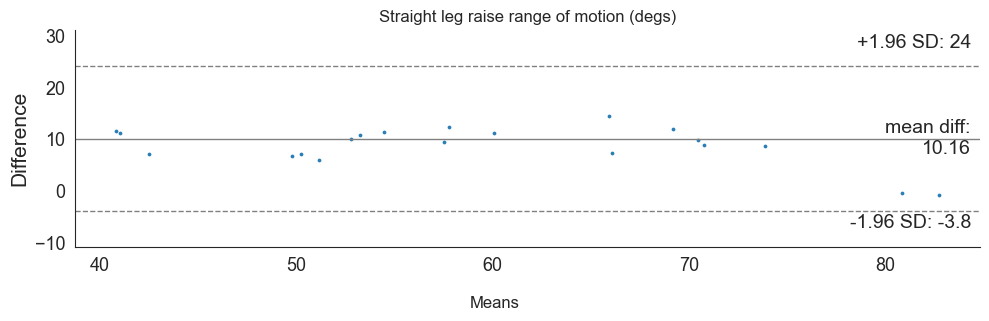

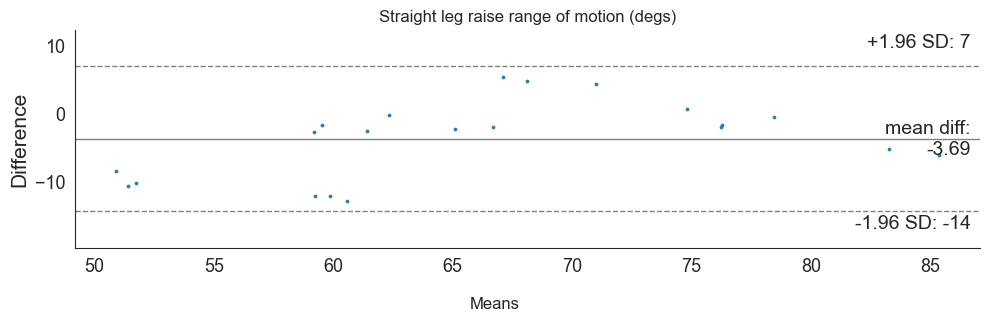

NORMAL (2D-norm):
            Metric                Task PTM Ref            Ground Truth    MAE  \
0  Range of motion  Straight leg raise     N/A  Optical motion capture  10.26   

   Reliability   ICC  
0         0.78  0.64  
WORLD (2D-world):
            Metric                Task PTM Ref            Ground Truth   MAE  \
0  Range of motion  Straight leg raise     N/A  Optical motion capture  5.14   

   Reliability   ICC  
0         0.94  0.81  


In [ ]:
import glob
from tasks import slr
from utilities import utils

slr_normal = sorted(p for p in glob.glob("data/keypoints/slr/*.txt")
                    if "world" not in p.lower())
slr_world = sorted(p for p in glob.glob("data/keypoints/slr/*.txt")
                   if "world" in p.lower())
slr_data = utils.read_list('slr_data')

m_normal = slr.get_metrics(slr_normal, slr_data)
m_world  = slr.get_metrics(slr_world, slr_data)
print("NORMAL (2D-norm):"); print(m_normal)
print("WORLD (2D-world):"); print(m_world)

[hip] P06 her: 3/2 reps, skipped


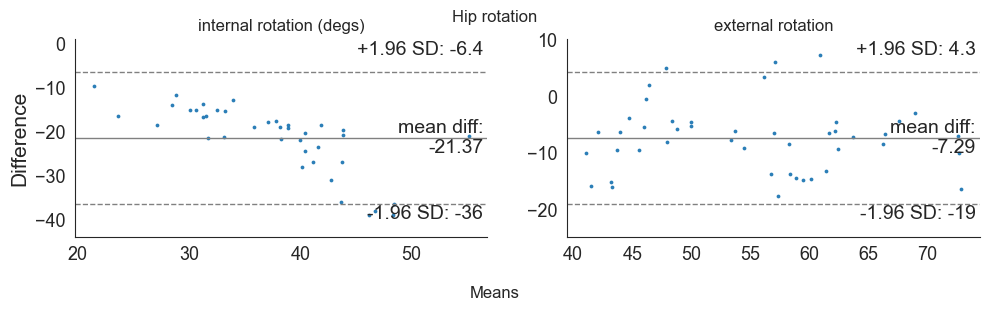

[hip] P06 her: 3/2 reps, skipped
[hip] P14 her: 3/2 reps, skipped


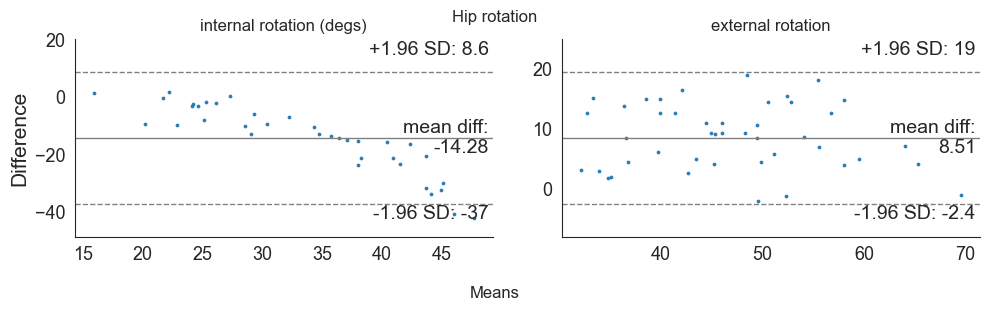

NORMAL (2D-norm):
            Metric                   Task PTM Ref            Ground Truth  \
0  Range of motion  Hip internal rotation     N/A  Optical motion capture   
1  Range of motion  Hip external rotation     N/A  Optical motion capture   

     MAE  Reliability   ICC  
0  21.37         0.87  0.13  
1   8.36         0.94  0.63  
WORLD (2D-world):
            Metric                   Task PTM Ref            Ground Truth  \
0  Range of motion  Hip internal rotation     N/A  Optical motion capture   
1  Range of motion  Hip external rotation     N/A  Optical motion capture   

     MAE  Reliability   ICC  
0  14.49         0.94  0.20  
1   8.80         0.94  0.62  


In [ ]:
import glob, os
from tasks import hip
from utilities import utils
import numpy as np, pandas as pd

hip_data = utils.read_list('hip_data')

# NORMAL — current behaviour
m_normal = hip.get_metrics("data/keypoints/hip", hip_data)

# WORLD — temporarily patch _find_file to prefer world files
_orig_find = hip._find_file
def _find_world(folder, sid, task):
    import re
    cands = [p for p in glob.glob(f"{folder}/*.txt")
             if "world" in p.lower() and sid in os.path.basename(p)]
    for p in cands:
        name = os.path.basename(p).upper()
        if task == "her" and re.search(r"(^|_)H?ER(_|\b)|HIP_ER", name):
            return p
        if task == "hir" and re.search(r"(^|_)H?IR(_|\b)|HIP_IR", name):
            return p
    return None
hip._find_file = _find_world
m_world = hip.get_metrics("data/keypoints/hip", hip_data)
hip._find_file = _orig_find   # restore

print("NORMAL (2D-norm):"); print(m_normal)
print("WORLD (2D-world):"); print(m_world)

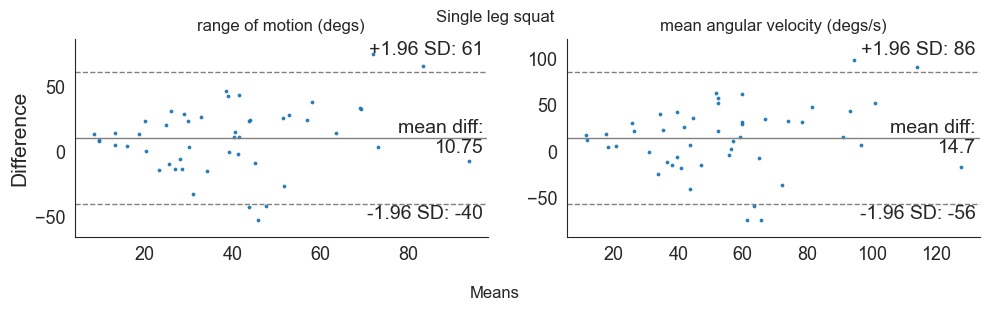

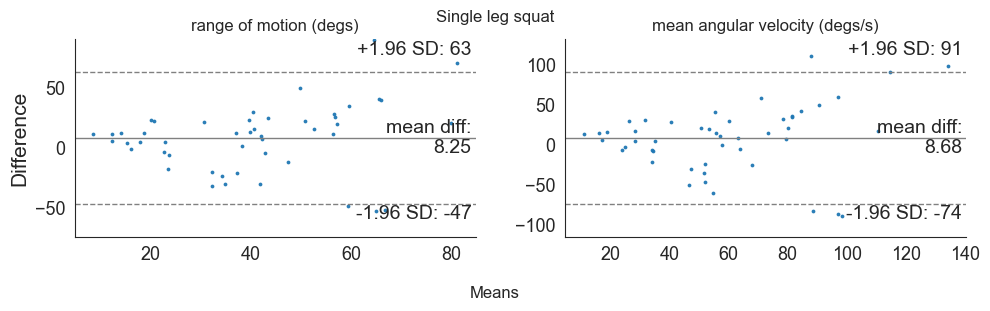

NORMAL (2D-norm):
             Metric              Task PTM Ref            Ground Truth    MAE  \
0   Range of motion  Single leg squat     N/A  Optical motion capture  22.41   
1  Angular velocity  Single leg squat     N/A  Optical motion capture  31.23   

   Reliability   ICC  
0         0.54  0.36  
1         0.53  0.32  
WORLD (2D-world):
             Metric              Task PTM Ref            Ground Truth    MAE  \
0   Range of motion  Single leg squat     N/A  Optical motion capture  22.94   
1  Angular velocity  Single leg squat     N/A  Optical motion capture  32.68   

   Reliability   ICC  
0         0.75  0.26  
1         0.76  0.29  


In [ ]:
import glob
from tasks import sls
from utilities import utils

sls_data = utils.read_list('sls_data')

sls_normal = sorted(p for p in glob.glob("data/keypoints/slsq/*.txt")
                    if "world" not in p.lower())
sls_world = sorted(p for p in glob.glob("data/keypoints/slsq/*.txt")
                   if "world" in p.lower())

m_normal = sls.get_metrics(sls_normal, sls_data)
m_world  = sls.get_metrics(sls_world, sls_data)
print("NORMAL (2D-norm):"); print(m_normal)
print("WORLD (2D-world):"); print(m_world)

# Full pipeline for Nortic

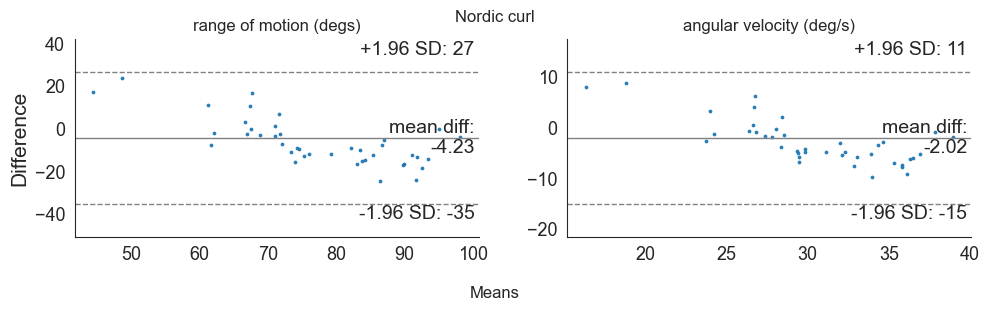

             Metric         Task PTM Ref            Ground Truth    MAE  \
0   Range of motion  Nordic curl     N/A  Optical motion capture  11.93   
1  Angular velocity  Nordic curl     N/A  Optical motion capture   5.04   

   Reliability   ICC  
0         0.60  0.41  
1         0.58  0.39  


In [ ]:
m = nordic.get_metrics(ndc_normal, nordic_data, ndims=2)
print(m)   # must be ROM 11.93/0.41

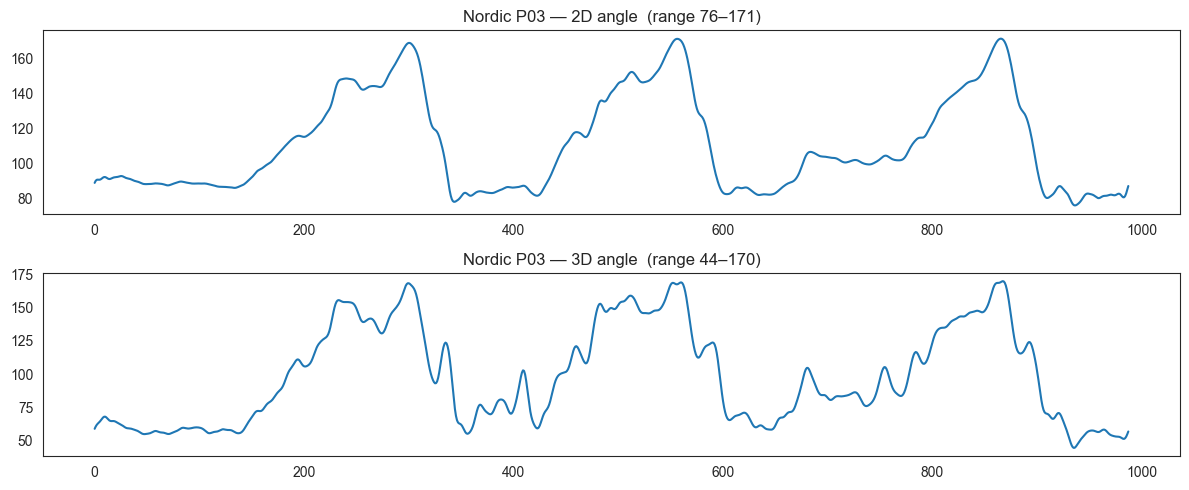

In [ ]:
import matplotlib.pyplot as plt
fp = next(p for p in ndc_normal if "P03" in p)
ang2d = nordic._mmc_angle(fp, nordic.MMC_START_DEFAULT, ndims=2)
ang3d = nordic._mmc_angle(fp, nordic.MMC_START_DEFAULT, ndims=3)
fig, axs = plt.subplots(2,1, figsize=(12,5))
axs[0].plot(ang2d); axs[0].set_title(f"Nordic P03 — 2D angle  (range {ang2d.min():.0f}–{ang2d.max():.0f})")
axs[1].plot(ang3d); axs[1].set_title(f"Nordic P03 — 3D angle  (range {ang3d.min():.0f}–{ang3d.max():.0f})")
plt.tight_layout(); plt.show()

2D-norm: 


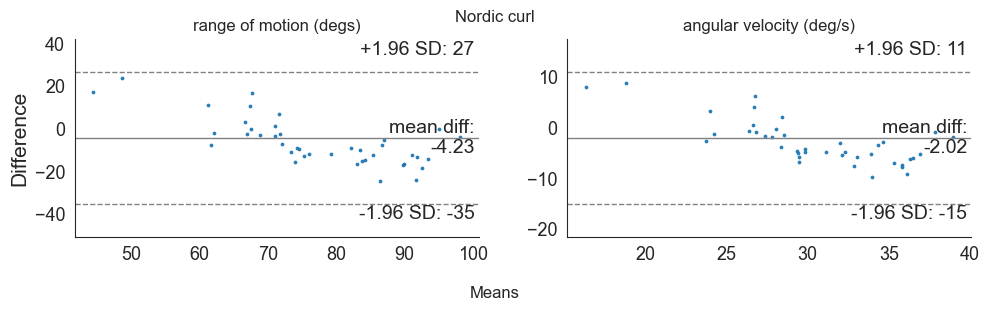

             Metric         Task PTM Ref            Ground Truth    MAE  \
0   Range of motion  Nordic curl     N/A  Optical motion capture  11.93   
1  Angular velocity  Nordic curl     N/A  Optical motion capture   5.04   

   Reliability   ICC  
0         0.60  0.41  
1         0.58  0.39  
2D-world:


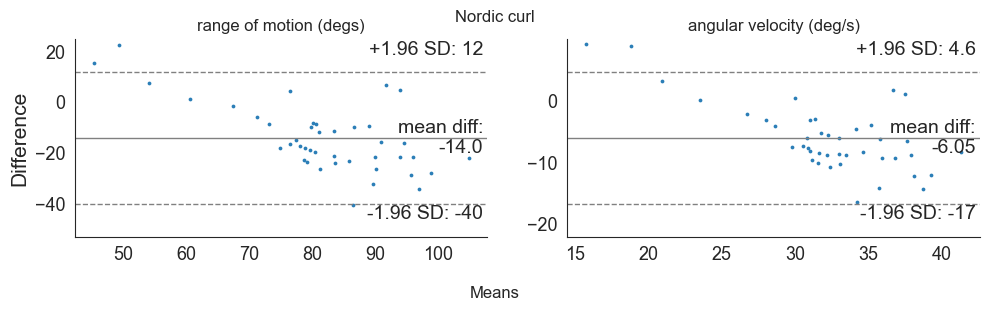

             Metric         Task PTM Ref            Ground Truth    MAE  \
0   Range of motion  Nordic curl     N/A  Optical motion capture  17.05   
1  Angular velocity  Nordic curl     N/A  Optical motion capture   7.21   

   Reliability   ICC  
0         0.57  0.39  
1         0.57  0.38  
3D-norm: 


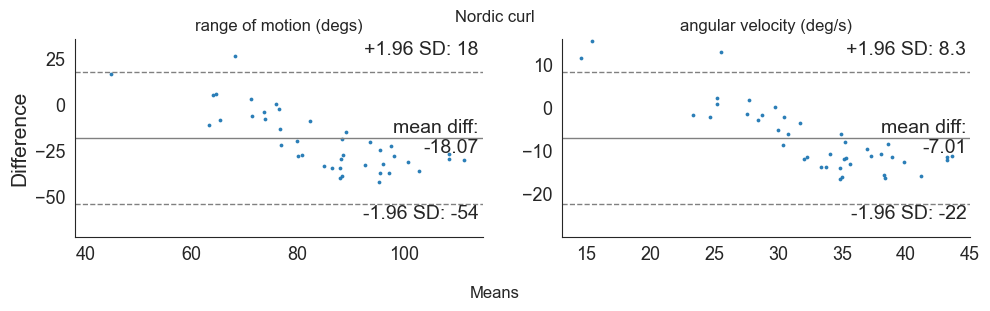

             Metric         Task PTM Ref            Ground Truth    MAE  \
0   Range of motion  Nordic curl     N/A  Optical motion capture  22.67   
1  Angular velocity  Nordic curl     N/A  Optical motion capture   9.17   

   Reliability   ICC  
0         0.58  0.32  
1         0.54  0.34  
3D-world:


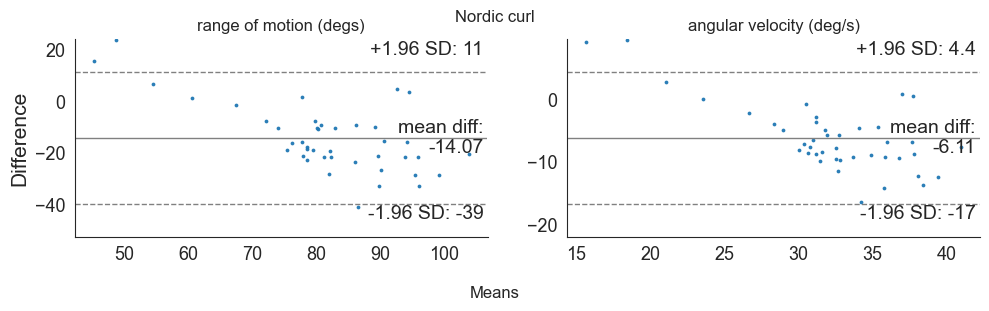

             Metric         Task PTM Ref            Ground Truth    MAE  \
0   Range of motion  Nordic curl     N/A  Optical motion capture  16.84   
1  Angular velocity  Nordic curl     N/A  Optical motion capture   7.22   

   Reliability   ICC  
0         0.58  0.39  
1         0.58  0.38  


In [ ]:
print("2D-norm: "); print(nordic.get_metrics(ndc_normal, nordic_data, ndims=2))
print("2D-world:"); print(nordic.get_metrics(ndc_world, nordic_data, ndims=2))
print("3D-norm: "); print(nordic.get_metrics(ndc_normal, nordic_data, ndims=3))
print("3D-world:"); print(nordic.get_metrics(ndc_world, nordic_data, ndims=3))

# Full pipeline for SLR

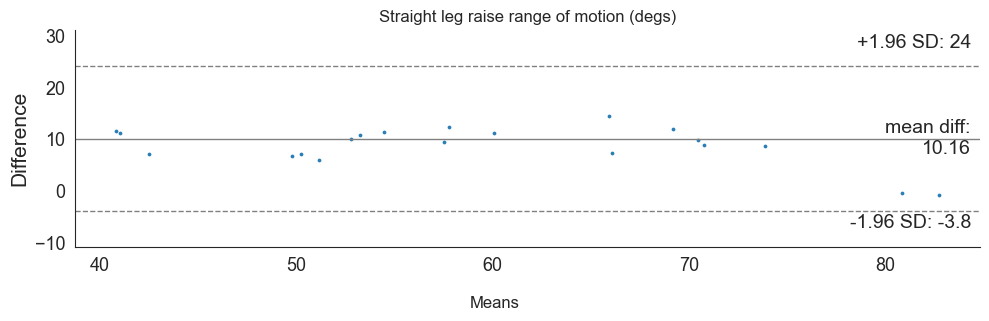

            Metric                Task PTM Ref            Ground Truth    MAE  \
0  Range of motion  Straight leg raise     N/A  Optical motion capture  10.26   

   Reliability   ICC  
0         0.78  0.64  


In [ ]:
print(slr.get_metrics(slr_normal, slr_data, ndims=2))

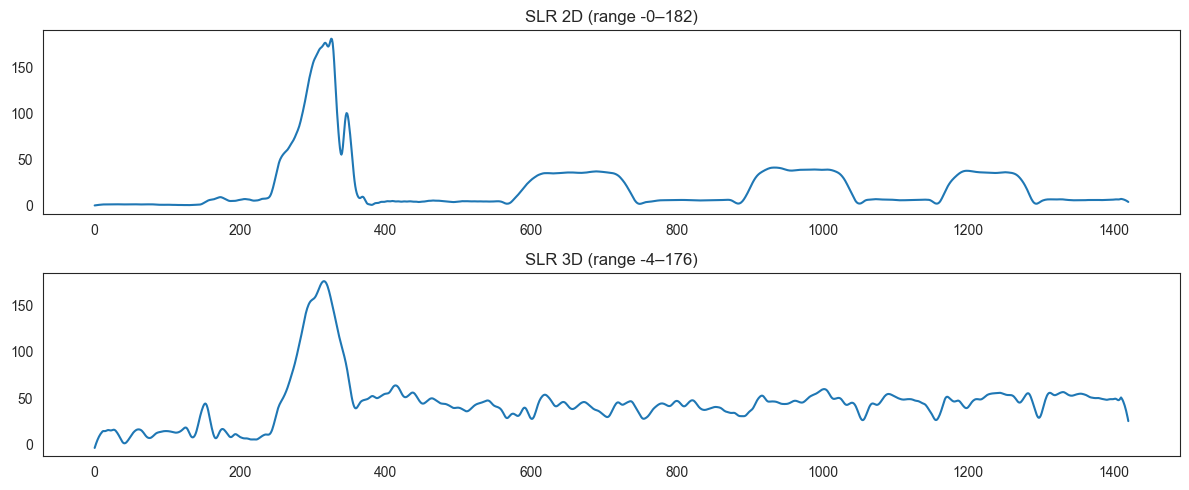

In [ ]:
import matplotlib.pyplot as plt
fp = next(p for p in slr_normal if "P11" in p)   # P11 isn't excluded
a2 = slr._mmc_angle(fp, 0, ndims=2)
a3 = slr._mmc_angle(fp, 0, ndims=3)
fig, axs = plt.subplots(2,1, figsize=(12,5))
axs[0].plot(a2); axs[0].set_title(f"SLR 2D (range {a2.min():.0f}–{a2.max():.0f})")
axs[1].plot(a3); axs[1].set_title(f"SLR 3D (range {a3.min():.0f}–{a3.max():.0f})")
plt.tight_layout(); plt.show()

2D-norm: 


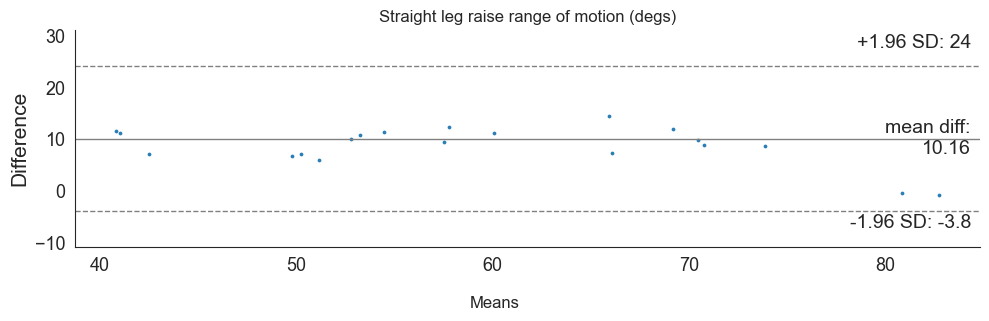

            Metric                Task PTM Ref            Ground Truth    MAE  \
0  Range of motion  Straight leg raise     N/A  Optical motion capture  10.26   

   Reliability   ICC  
0         0.78  0.64  
2D-world:


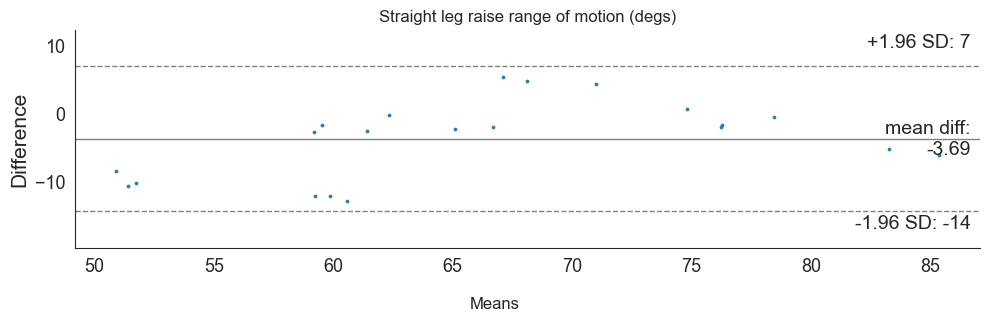

            Metric                Task PTM Ref            Ground Truth   MAE  \
0  Range of motion  Straight leg raise     N/A  Optical motion capture  5.14   

   Reliability   ICC  
0         0.94  0.81  
3D-norm: 
[slr] P11: only 3/1 reps, skipped
[slr] P15: only 3/1 reps, skipped


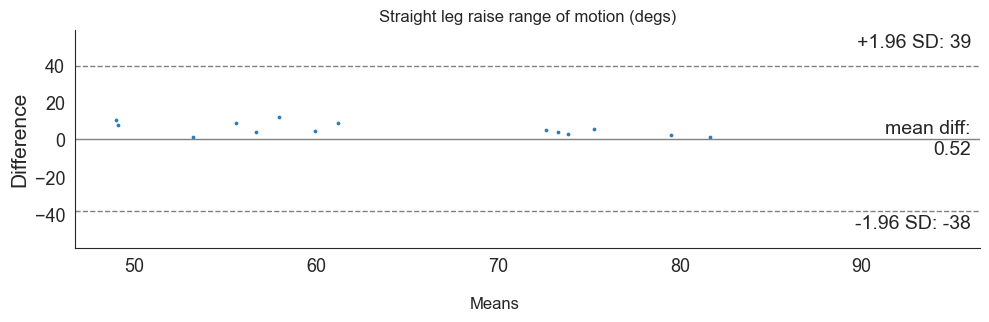

            Metric                Task PTM Ref            Ground Truth    MAE  \
0  Range of motion  Straight leg raise     N/A  Optical motion capture  10.22   

   Reliability   ICC  
0          0.2  0.28  
3D-world:


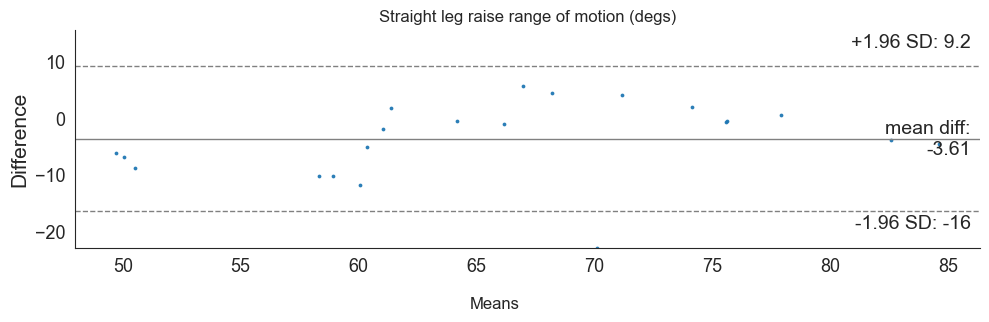

            Metric                Task PTM Ref            Ground Truth   MAE  \
0  Range of motion  Straight leg raise     N/A  Optical motion capture  5.39   

   Reliability   ICC  
0         0.76  0.77  


In [ ]:
print("2D-norm: "); print(slr.get_metrics(slr_normal, slr_data, ndims=2))
print("2D-world:"); print(slr.get_metrics(slr_world, slr_data, ndims=2))
print("3D-norm: "); print(slr.get_metrics(slr_normal, slr_data, ndims=3))
print("3D-world:"); print(slr.get_metrics(slr_world, slr_data, ndims=3))

# SLS

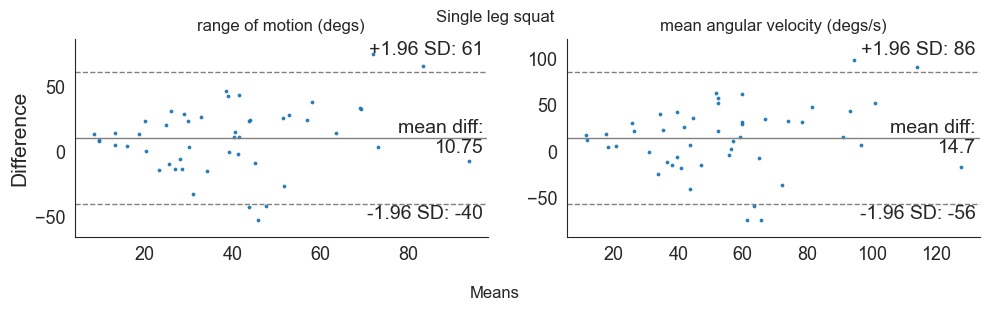

             Metric              Task PTM Ref            Ground Truth    MAE  \
0   Range of motion  Single leg squat     N/A  Optical motion capture  22.41   
1  Angular velocity  Single leg squat     N/A  Optical motion capture  31.23   

   Reliability   ICC  
0         0.54  0.36  
1         0.53  0.32  


In [ ]:
print(sls.get_metrics(sls_normal, sls_data, ndims=2))

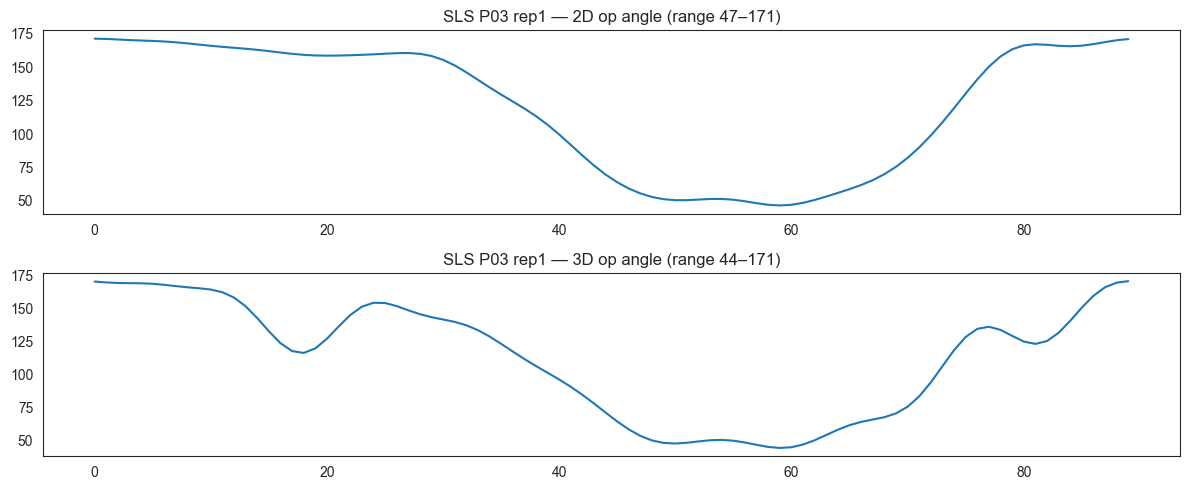

In [ ]:
import matplotlib.pyplot as plt
fp = next(p for p in sls_normal if "P03" in p)
p = sls_data[0]
co2, op2 = sls._roms_for_subject(fp, p, 0, ndims=2)
co3, op3 = sls._roms_for_subject(fp, p, 0, ndims=3)
fig, axs = plt.subplots(2,1, figsize=(12,5))
axs[0].plot(op2[0]); axs[0].set_title(f"SLS P03 rep1 — 2D op angle (range {op2[0].min():.0f}–{op2[0].max():.0f})")
axs[1].plot(op3[0]); axs[1].set_title(f"SLS P03 rep1 — 3D op angle (range {op3[0].min():.0f}–{op3[0].max():.0f})")
plt.tight_layout(); plt.show()

2D-norm: 


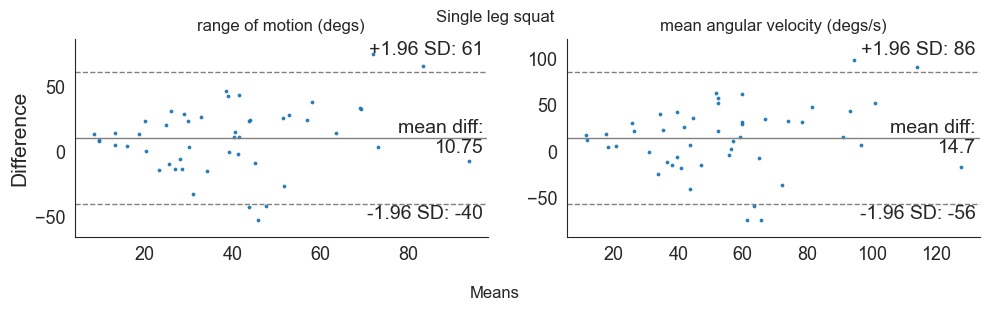

             Metric              Task PTM Ref            Ground Truth    MAE  \
0   Range of motion  Single leg squat     N/A  Optical motion capture  22.41   
1  Angular velocity  Single leg squat     N/A  Optical motion capture  31.23   

   Reliability   ICC  
0         0.54  0.36  
1         0.53  0.32  
2D-world:


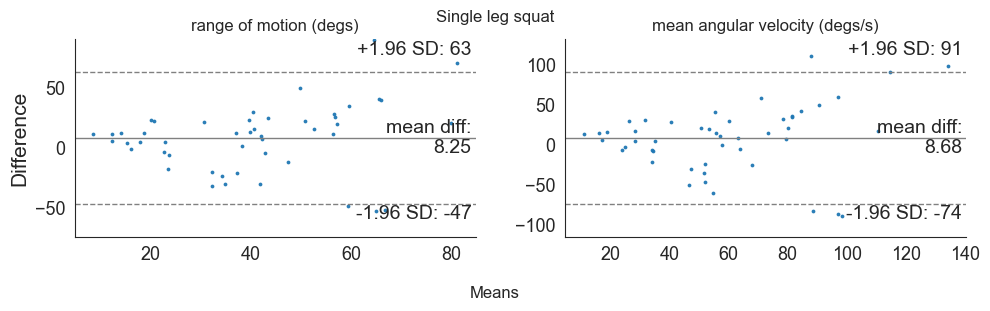

             Metric              Task PTM Ref            Ground Truth    MAE  \
0   Range of motion  Single leg squat     N/A  Optical motion capture  22.94   
1  Angular velocity  Single leg squat     N/A  Optical motion capture  32.68   

   Reliability   ICC  
0         0.75  0.26  
1         0.76  0.29  
3D-norm: 


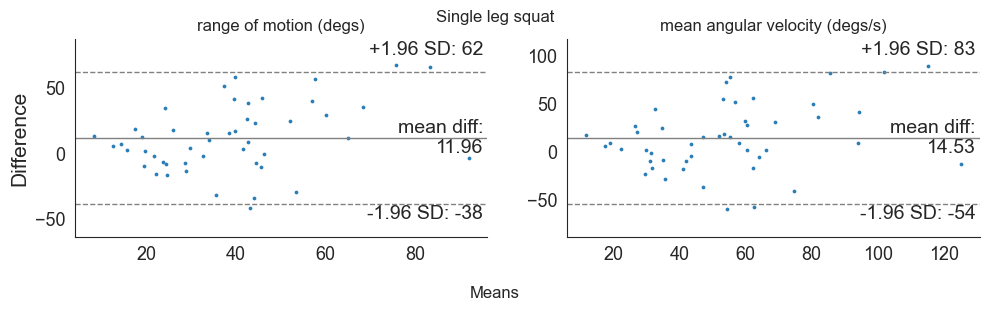

             Metric              Task PTM Ref            Ground Truth    MAE  \
0   Range of motion  Single leg squat     N/A  Optical motion capture  21.89   
1  Angular velocity  Single leg squat     N/A  Optical motion capture  29.02   

   Reliability   ICC  
0         0.48  0.29  
1         0.47  0.31  
3D-world:


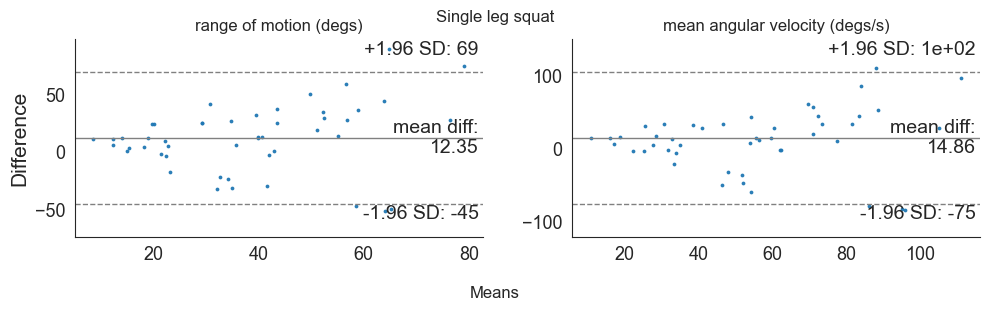

             Metric              Task PTM Ref            Ground Truth    MAE  \
0   Range of motion  Single leg squat     N/A  Optical motion capture  25.06   
1  Angular velocity  Single leg squat     N/A  Optical motion capture  35.77   

   Reliability   ICC  
0         0.72  0.19  
1         0.75  0.13  


In [ ]:
print("2D-norm: "); print(sls.get_metrics(sls_normal, sls_data, ndims=2))
print("2D-world:"); print(sls.get_metrics(sls_world, sls_data, ndims=2))
print("3D-norm: "); print(sls.get_metrics(sls_normal, sls_data, ndims=3))
print("3D-world:"); print(sls.get_metrics(sls_world, sls_data, ndims=3))

# Hip

In [ ]:
# for world runs, patch _find_file to find world files (from earlier)
_orig_find = hip._find_file
def _find_world(folder, sid, task):
    import re, glob, os
    cands = [p for p in glob.glob(f"{folder}/*.txt")
             if "world" in p.lower() and sid in os.path.basename(p)]
    for p in cands:
        name = os.path.basename(p).upper()
        if task == "her" and re.search(r"(^|_)H?ER(_|\b)|HIP_ER", name):
            return p
        if task == "hir" and re.search(r"(^|_)H?IR(_|\b)|HIP_IR", name):
            return p
    return None


[hip] P06 her: 3/2 reps, skipped


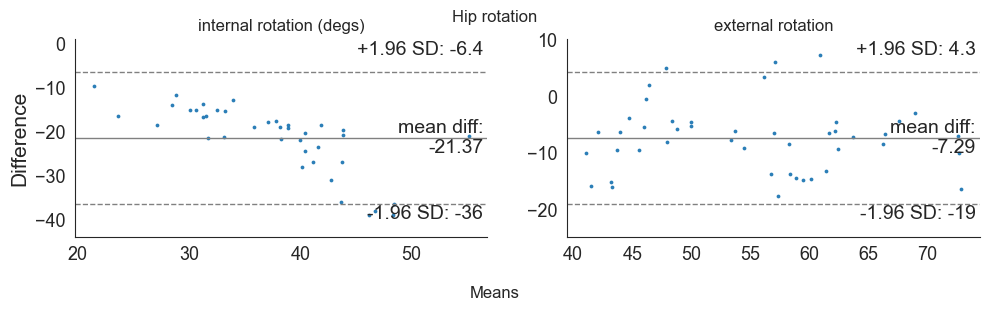

            Metric                   Task PTM Ref            Ground Truth  \
0  Range of motion  Hip internal rotation     N/A  Optical motion capture   
1  Range of motion  Hip external rotation     N/A  Optical motion capture   

     MAE  Reliability   ICC  
0  21.37         0.87  0.13  
1   8.36         0.94  0.63  


In [ ]:
print(hip.get_metrics("data/keypoints/hip", hip_data, ndims=2))

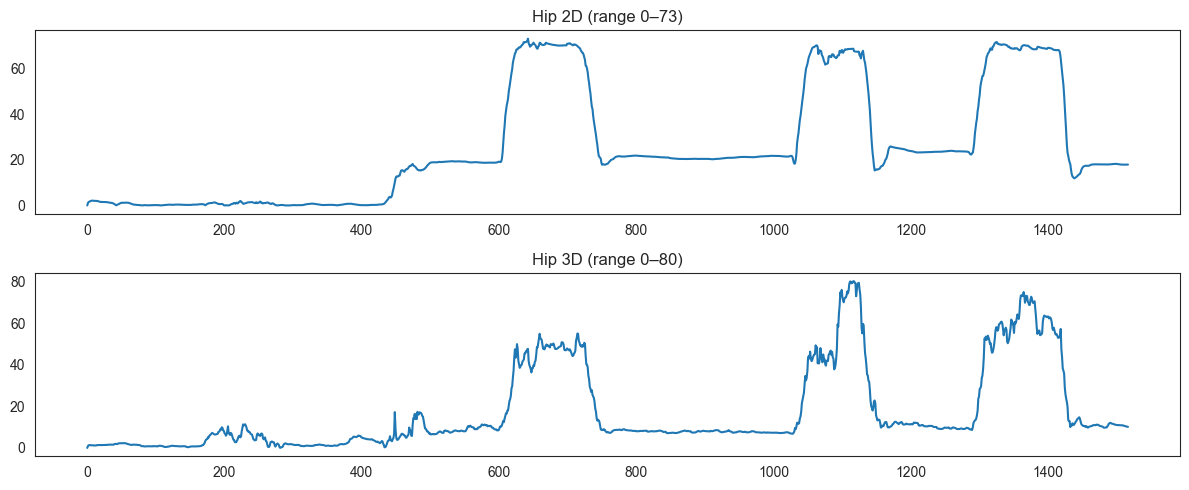

In [ ]:
import matplotlib.pyplot as plt
fp = hip._find_file("data/keypoints/hip", "P03", "hir")
a2 = hip._mmc_angle(fp, ndims=2)
a3 = hip._mmc_angle(fp, ndims=3)
fig, axs = plt.subplots(2,1, figsize=(12,5))
axs[0].plot(a2); axs[0].set_title(f"Hip 2D (range {a2.min():.0f}–{a2.max():.0f})")
axs[1].plot(a3); axs[1].set_title(f"Hip 3D (range {a3.min():.0f}–{a3.max():.0f})")
plt.tight_layout(); plt.show()

2D-norm: 
[hip] P06 her: 3/2 reps, skipped


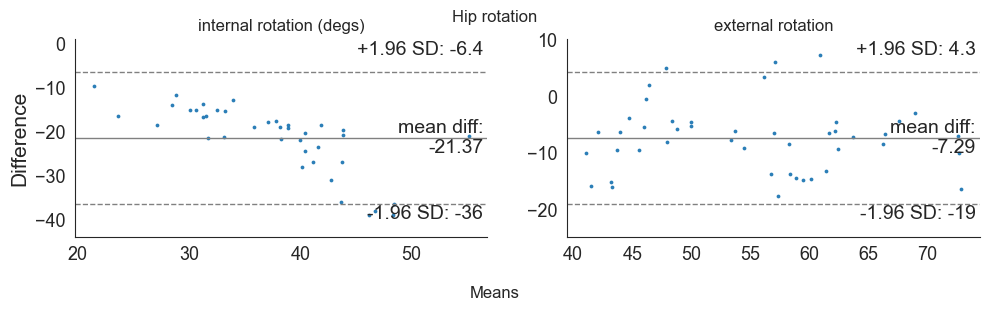

            Metric                   Task PTM Ref            Ground Truth  \
0  Range of motion  Hip internal rotation     N/A  Optical motion capture   
1  Range of motion  Hip external rotation     N/A  Optical motion capture   

     MAE  Reliability   ICC  
0  21.37         0.87  0.13  
1   8.36         0.94  0.63  
2D-world:
[hip] P06 her: 3/2 reps, skipped
[hip] P14 her: 3/2 reps, skipped


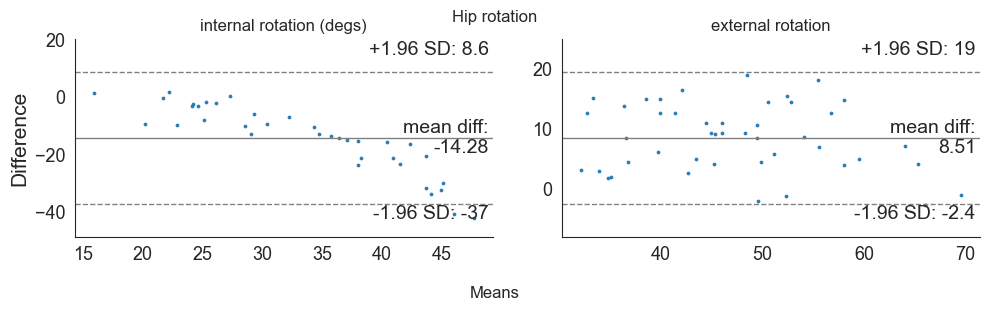

            Metric                   Task PTM Ref            Ground Truth  \
0  Range of motion  Hip internal rotation     N/A  Optical motion capture   
1  Range of motion  Hip external rotation     N/A  Optical motion capture   

     MAE  Reliability   ICC  
0  14.49         0.94  0.20  
1   8.80         0.94  0.62  
3D-norm: 
[hip] P05 her: 3/2 reps, skipped
[hip] P06 her: 3/2 reps, skipped
[hip] P14 her: 3/1 reps, skipped
[hip] P15 hir: 3/2 reps, skipped
[hip] P16 hir: 3/1 reps, skipped


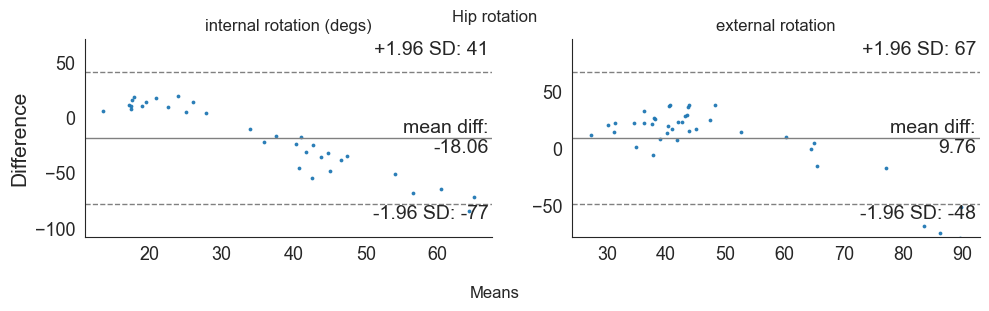

            Metric                   Task PTM Ref            Ground Truth  \
0  Range of motion  Hip internal rotation     N/A  Optical motion capture   
1  Range of motion  Hip external rotation     N/A  Optical motion capture   

     MAE  Reliability   ICC  
0  28.41         0.87 -0.02  
1  25.41         0.89  0.13  
3D-world:
[hip] P06 her: 3/2 reps, skipped
[hip] P14 her: 3/2 reps, skipped


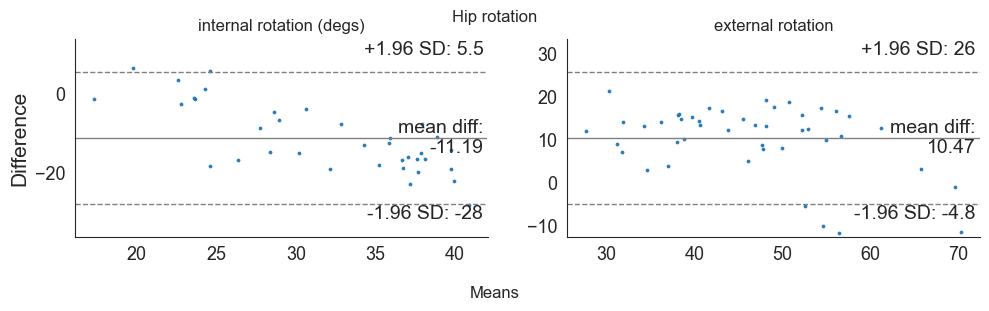

            Metric                   Task PTM Ref            Ground Truth  \
0  Range of motion  Hip internal rotation     N/A  Optical motion capture   
1  Range of motion  Hip external rotation     N/A  Optical motion capture   

     MAE  Reliability   ICC  
0  12.16         0.88  0.21  
1  12.21         0.93  0.52  


In [ ]:
print("2D-norm: "); print(hip.get_metrics("data/keypoints/hip", hip_data, ndims=2))
print("2D-world:")
hip._find_file = _find_world
print(hip.get_metrics("data/keypoints/hip", hip_data, ndims=2))
hip._find_file = _orig_find
print("3D-norm: "); print(hip.get_metrics("data/keypoints/hip", hip_data, ndims=3))
print("3D-world:")
hip._find_file = _find_world
print(hip.get_metrics("data/keypoints/hip", hip_data, ndims=3))
hip._find_file = _orig_find

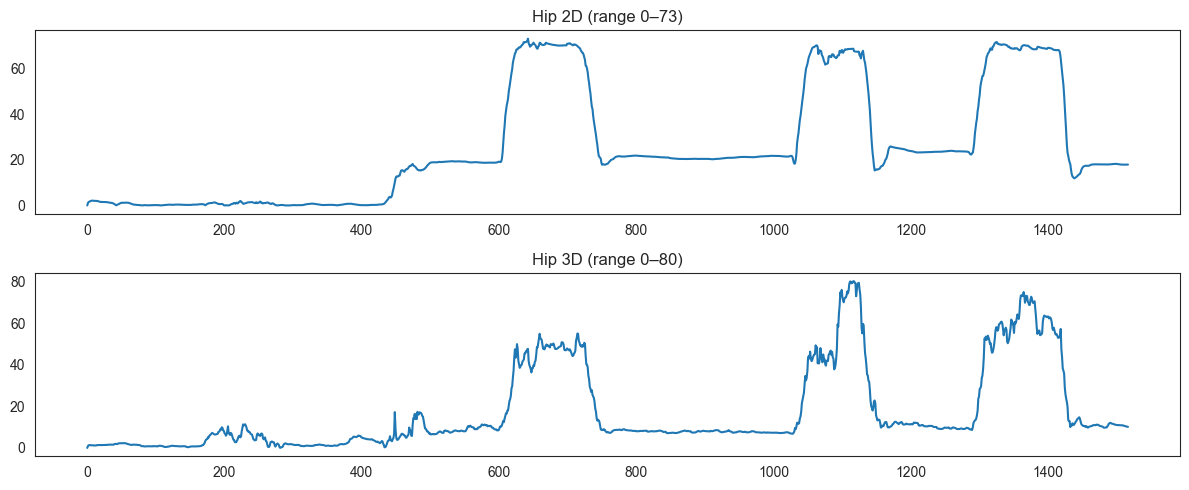

In [ ]:
import matplotlib.pyplot as plt
fp = hip._find_file("data/keypoints/hip", "P03", "hir")
a2 = hip._mmc_angle(fp, ndims=2)
a3 = hip._mmc_angle(fp, ndims=3)
fig, axs = plt.subplots(2,1, figsize=(12,5))
axs[0].plot(a2); axs[0].set_title(f"Hip 2D (range {a2.min():.0f}–{a2.max():.0f})")
axs[1].plot(a3); axs[1].set_title(f"Hip 3D (range {a3.min():.0f}–{a3.max():.0f})")
plt.tight_layout(); plt.show()

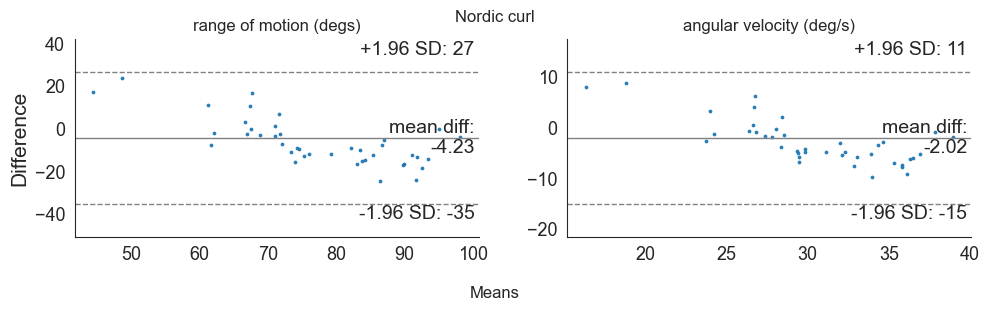

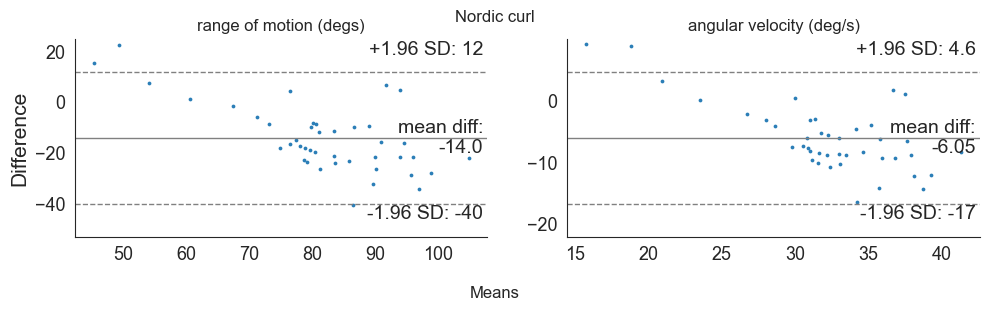

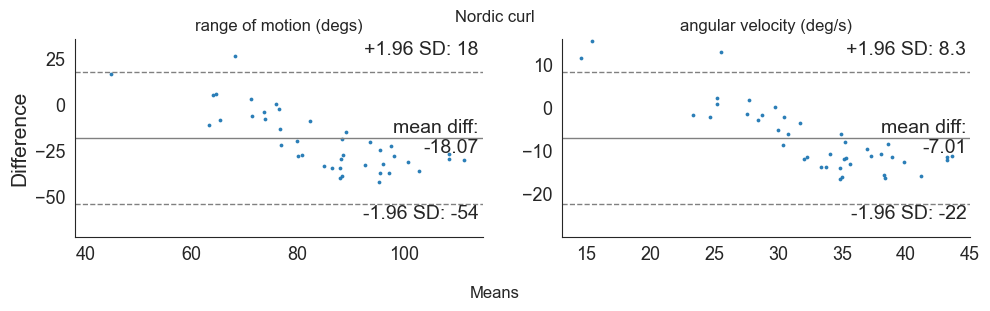

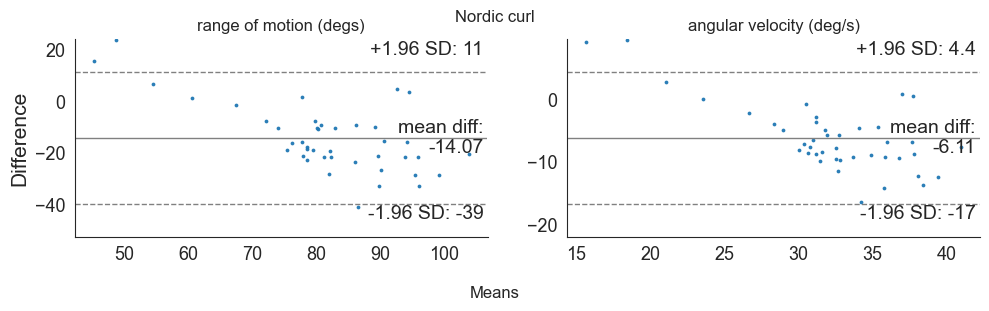

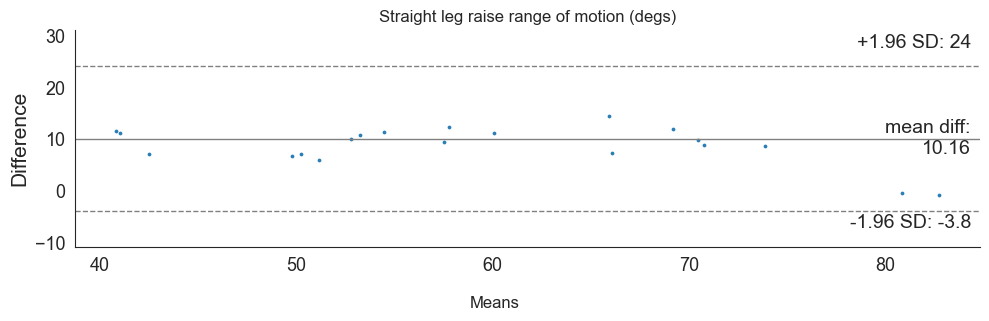

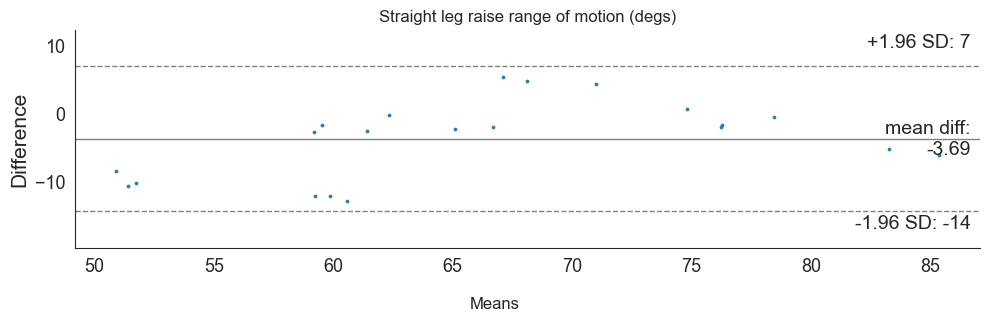

[slr] P11: only 3/1 reps, skipped
[slr] P15: only 3/1 reps, skipped


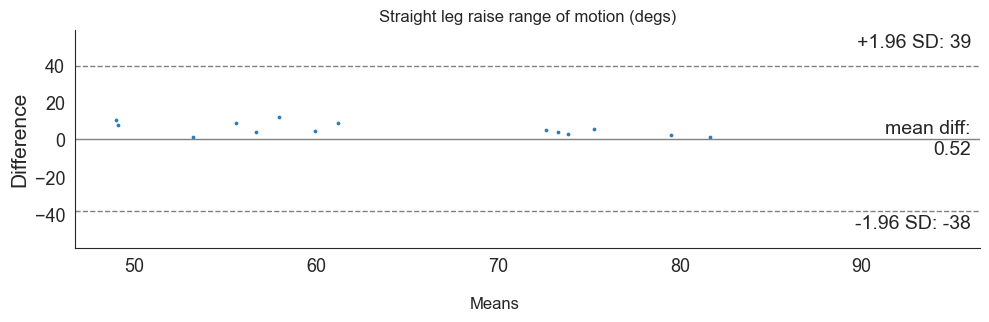

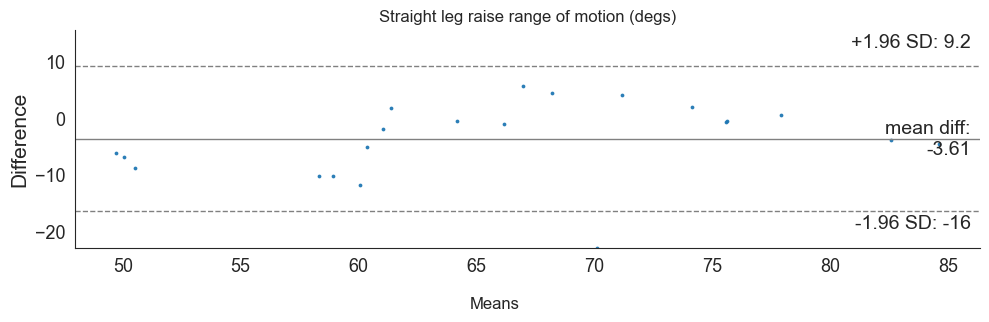

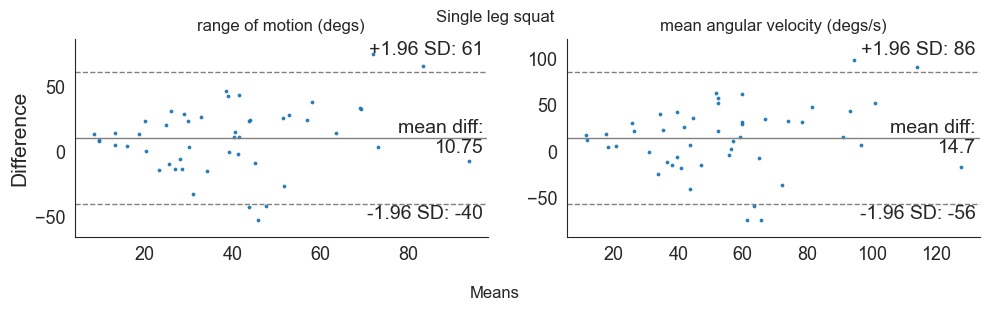

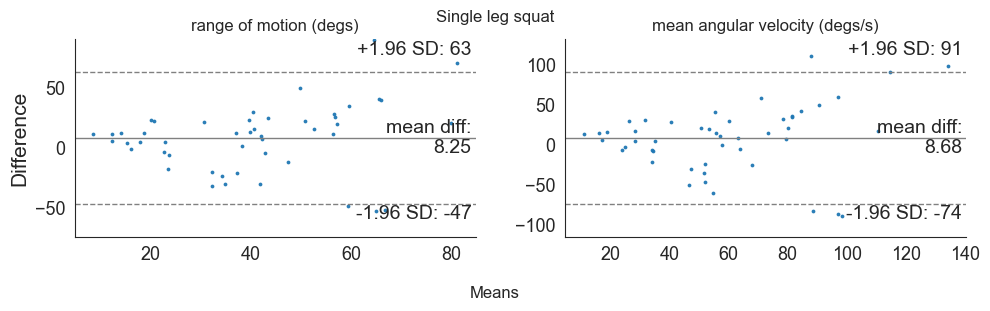

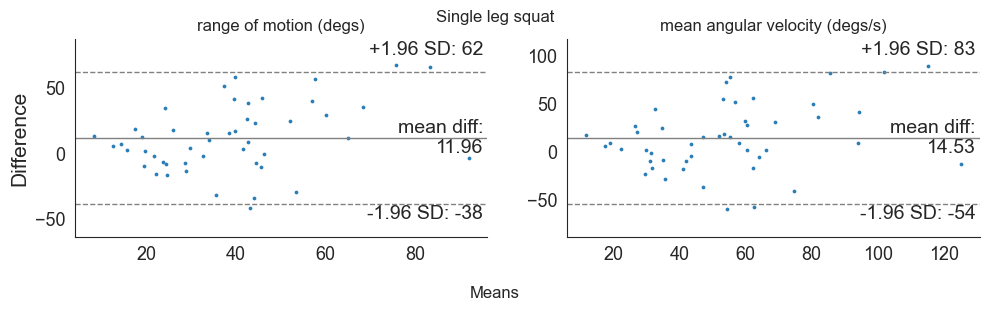

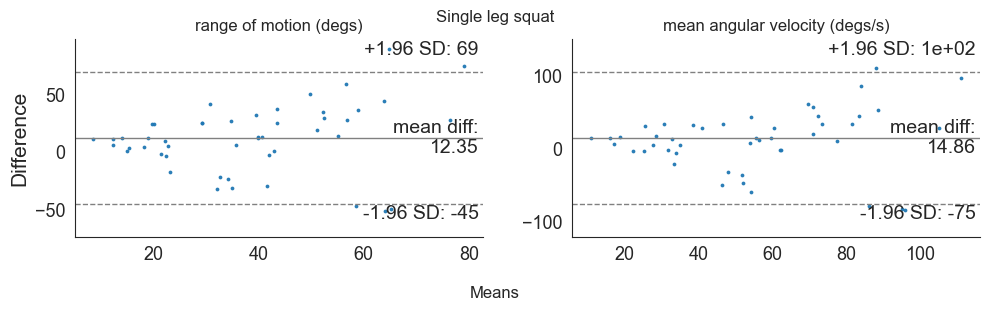

[hip] P06 her: 3/2 reps, skipped


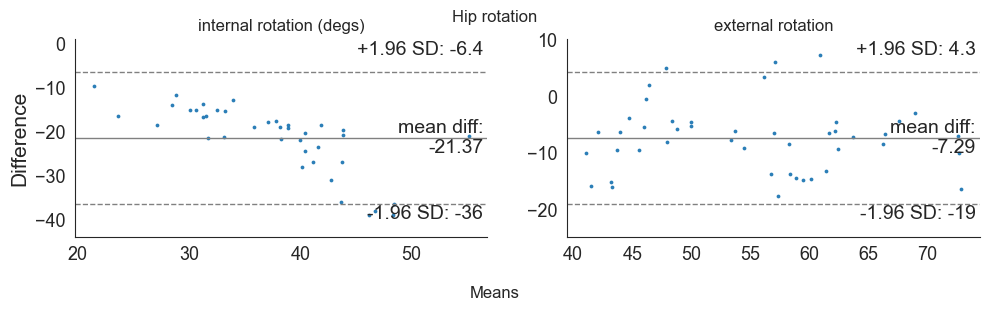

[hip] P06 her: 3/2 reps, skipped
[hip] P14 her: 3/2 reps, skipped


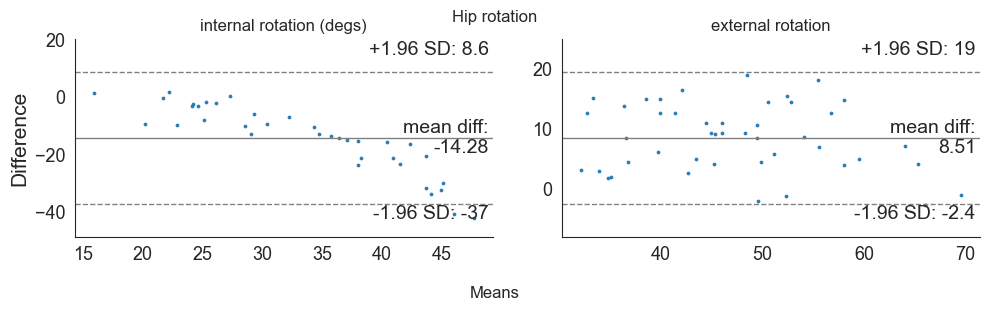

[hip] P05 her: 3/2 reps, skipped
[hip] P06 her: 3/2 reps, skipped
[hip] P14 her: 3/1 reps, skipped
[hip] P15 hir: 3/2 reps, skipped
[hip] P16 hir: 3/1 reps, skipped


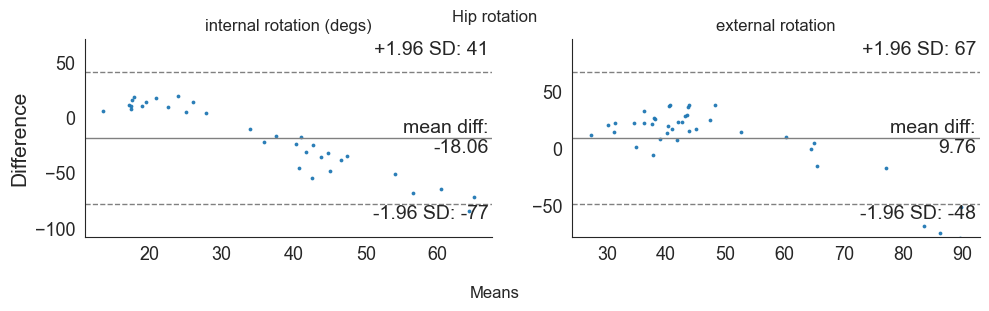

[hip] P06 her: 3/2 reps, skipped
[hip] P14 her: 3/2 reps, skipped


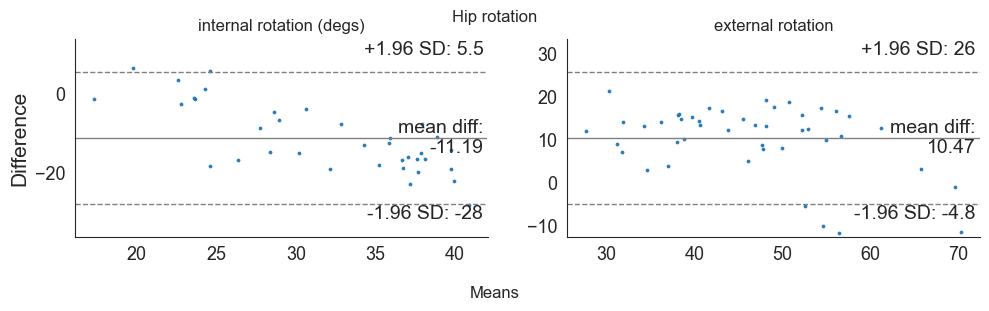

Method                                  2D-norm  2D-world  3D-norm  3D-world
Task                  Metric                                                
Hip external rotation Range of motion      8.36      8.80    25.41     12.21
Hip internal rotation Range of motion     21.37     14.49    28.41     12.16
Nordic curl           Angular velocity     5.04      7.21     9.17      7.22
                      Range of motion     11.93     17.05    22.67     16.84
Single leg squat      Angular velocity    31.23     32.68    29.02     35.77
                      Range of motion     22.41     22.94    21.89     25.06
Straight leg raise    Range of motion     10.26      5.14    10.22      5.39

saved both CSVs


In [ ]:

import pandas as pd, numpy as np

def four_methods(get_metrics_fn, normal_files, world_files, data, **kw):
    """Run a task's get_metrics for all four coordinate methods.
    Returns dict of method -> metrics dataframe."""
    return {
        "2D-norm":  get_metrics_fn(normal_files, data, ndims=2, **kw),
        "2D-world": get_metrics_fn(world_files,  data, ndims=2, **kw),
        "3D-norm":  get_metrics_fn(normal_files, data, ndims=3, **kw),
        "3D-world": get_metrics_fn(world_files,  data, ndims=3, **kw),
    }

# --- run each task (adjust variable names to your notebook) ---
results = {}
results["Nordic curl"]        = four_methods(nordic.get_metrics, ndc_normal, ndc_world, nordic_data)
results["Straight leg raise"] = four_methods(slr.get_metrics,    slr_normal, slr_world, slr_data)
results["Single leg squat"]   = four_methods(sls.get_metrics,    sls_normal, sls_world, sls_data)

# hip needs the world-file patch, so handle it separately:
_orig = hip._find_file
def _find_world(folder, sid, task):
    import re, glob, os
    cands = [p for p in glob.glob(f"{folder}/*.txt")
             if "world" in p.lower() and sid in os.path.basename(p)]
    for p in cands:
        name = os.path.basename(p).upper()
        if task == "her" and re.search(r"(^|_)H?ER(_|\b)|HIP_ER", name): return p
        if task == "hir" and re.search(r"(^|_)H?IR(_|\b)|HIP_IR", name): return p
    return None

hip_results = {}
hip_results["2D-norm"]  = hip.get_metrics("data/keypoints/hip", hip_data, ndims=2)
hip._find_file = _find_world
hip_results["2D-world"] = hip.get_metrics("data/keypoints/hip", hip_data, ndims=2)
hip._find_file = _orig
hip_results["3D-norm"]  = hip.get_metrics("data/keypoints/hip", hip_data, ndims=3)
hip._find_file = _find_world
hip_results["3D-world"] = hip.get_metrics("data/keypoints/hip", hip_data, ndims=3)
hip._find_file = _orig

# --- flatten everything into one long table ---
long_rows = []
def add(task, method, mdf):
    for _, r in mdf.iterrows():
        long_rows.append({
            "Task": r["Task"], "Metric": r["Metric"], "Method": method,
            "MAE": r["MAE"], "ICC": r["ICC"], "Reliability": r.get("Reliability", np.nan),
        })

for task, methods in results.items():
    for method, mdf in methods.items():
        add(task, method, mdf)
# hip has two rows (internal/external) per method
for method, mdf in hip_results.items():
    add("Hip", method, mdf)

long_df = pd.DataFrame(long_rows)

# --- pivot to the wide grid (MAE per method) for a readable table ---
grid = long_df.pivot_table(index=["Task","Metric"], columns="Method",
                           values="MAE", aggfunc="first")
grid = grid[["2D-norm","2D-world","3D-norm","3D-world"]]  # column order
print(grid)

# --- save both forms ---
import os
os.makedirs("results", exist_ok=True)
long_df.to_csv("results/coordinate_comparison_long.csv", index=False)
grid.to_csv("results/coordinate_comparison_grid.csv")
print("\nsaved both CSVs")

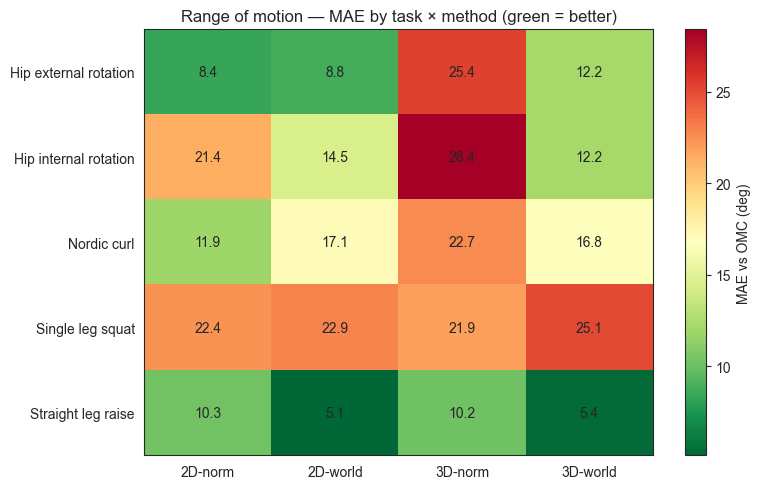

In [ ]:
import matplotlib.pyplot as plt
rom = grid.xs("Range of motion", level="Metric")
fig, ax = plt.subplots(figsize=(8,5))
im = ax.imshow(rom.values, cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(range(len(rom.columns))); ax.set_xticklabels(rom.columns)
ax.set_yticks(range(len(rom.index))); ax.set_yticklabels(rom.index)
for i in range(len(rom.index)):
    for j in range(len(rom.columns)):
        ax.text(j, i, f"{rom.values[i,j]:.1f}", ha="center", va="center")
ax.set_title("Range of motion — MAE by task × method (green = better)")
fig.colorbar(im, label="MAE vs OMC (deg)")
plt.tight_layout(); plt.savefig("results/coord_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()